<a href="https://colab.research.google.com/github/skandanyal/ML_Projects_in_Python/blob/main/torch1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# imports

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# device

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
# dataset

transform = transforms.ToTensor()

train_dataset = datasets.MNIST(
    "./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = datasets.MNIST(
    "./data",
    train=False,
    download=True,
    transform=transform
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

In [4]:
# build the mlp

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28*28, 256)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(256, 128)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

model = MLP().to(device)

In [5]:
# loss, optimizer

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    params=model.parameters(),
    lr=0.01
)

In [6]:
# metrics storage

training_acc = []
training_loss = []
validation_acc = []
validation_loss = []

In [7]:
# training function

def train_one_epoch(model, loader):
    model.train()

    running_loss = 0
    correct  = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        predictions = outputs.argmax(1)
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [8]:
# validation function

def validation(model, loader):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            running_loss += loss.item()
            predictions = outputs.argmax(1)

            correct += (predictions == labels).sum().item()
            total += labels.size(0)

    avg_loss = running_loss / len(loader)
    accuracy = correct / total

    return avg_loss, accuracy

In [9]:
# training loop

epochs = 10

for epoch in range(epochs):
    train_loss, train_acc = train_one_epoch(
        model, train_loader
    )
    val_loss, val_acc = validation(
        model, test_loader
    )

    training_loss.append(train_loss)
    training_acc.append(train_acc)
    validation_loss.append(val_loss)
    validation_acc.append(val_acc)

    print(
        f"Epoch {epoch+1:2d} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc:.4f} | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc:.4f}"
    )

Epoch  1 | Train Loss 0.2314 | Train Acc 0.9300 | Val Loss 0.1392 | Val Acc 0.9567
Epoch  2 | Train Loss 0.1193 | Train Acc 0.9652 | Val Loss 0.1229 | Val Acc 0.9664
Epoch  3 | Train Loss 0.1052 | Train Acc 0.9702 | Val Loss 0.1355 | Val Acc 0.9598
Epoch  4 | Train Loss 0.0847 | Train Acc 0.9756 | Val Loss 0.1208 | Val Acc 0.9696
Epoch  5 | Train Loss 0.0903 | Train Acc 0.9749 | Val Loss 0.1111 | Val Acc 0.9733
Epoch  6 | Train Loss 0.0761 | Train Acc 0.9785 | Val Loss 0.1391 | Val Acc 0.9679
Epoch  7 | Train Loss 0.0688 | Train Acc 0.9811 | Val Loss 0.1485 | Val Acc 0.9641
Epoch  8 | Train Loss 0.0665 | Train Acc 0.9821 | Val Loss 0.1491 | Val Acc 0.9688
Epoch  9 | Train Loss 0.0630 | Train Acc 0.9830 | Val Loss 0.1603 | Val Acc 0.9708
Epoch 10 | Train Loss 0.0728 | Train Acc 0.9810 | Val Loss 0.1724 | Val Acc 0.9688


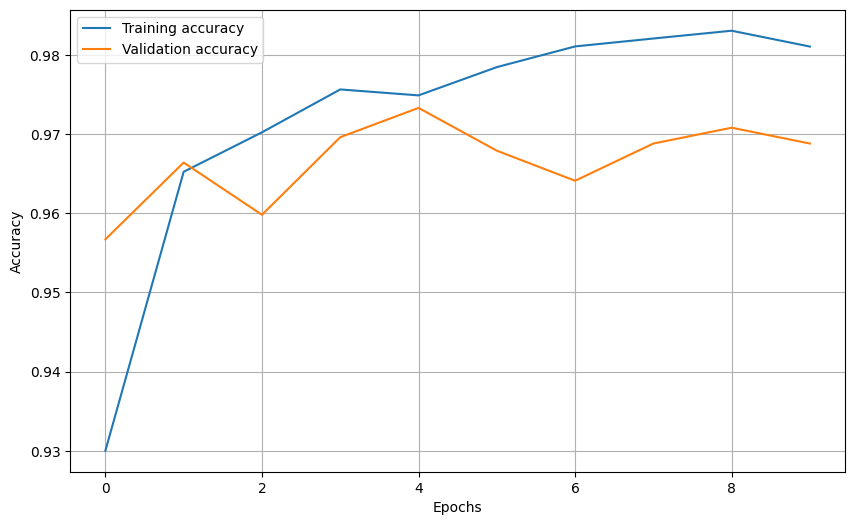

In [10]:
# plotting

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(training_acc, label="Training accuracy")
plt.plot(validation_acc, label='Validation accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

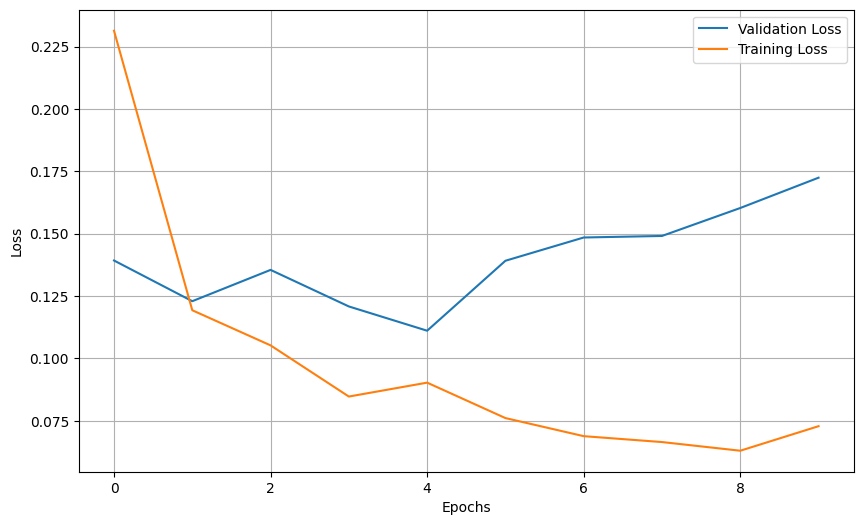

In [11]:
plt.figure(figsize=(10,6))
plt.plot(validation_loss, label="Validation Loss")
plt.plot(training_loss, label="Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [12]:
print(type(training_loss[0]))
print(training_loss[0])

<class 'float'>
0.23136956610881698
